<a href="https://colab.research.google.com/github/codeshujaa/Plasmodium-Life-Stage-Detection/blob/main/Plasmodium_Life_Stage_Detection_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics --upgrade -q

In [ ]:
import os
import cv2
import shutil
import numpy as np
import pandas as pd
import torch
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from torch.utils.tensorboard import SummaryWriter
from huggingface_hub import HfApi, login
from ultralytics import YOLO

2026-03-20 18:31:26.085623: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774031486.110714     269 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774031486.119282     269 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774031486.143210     269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774031486.143235     269 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774031486.143237     269 computation_placer.cc:177] computation placer alr

In [ ]:
HF_TOKEN =
HF_REPO_ID =

login(token=HF_TOKEN)

In [ ]:
# GPUs
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True,max_split_size_mb:512'
gc.collect()
torch.cuda.empty_cache()

for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")

GPU 0: Tesla T4
Memory: 15.64 GB
GPU 1: Tesla T4
Memory: 15.64 GB


In [ ]:

DATASET_DIR  = '/kaggle/input/datasets/colabsandbox/plasmodium-merged-v2'
RUNS_DIR     = '/kaggle/working/runs/plasmodium_v2'
WEIGHTS_DIR  = '/kaggle/working/yolo26_plasmodium_v2'

CLASS_NAMES  = ['Ring', 'Schizont', 'Trophozoite']

IMAGE_SIZE   = 640
EPOCHS       = 120
BATCH_SIZE   = 4

In [ ]:
# yaml
DATASET_DIR = '/kaggle/input/datasets/colabsandbox/plasmodium-merged-v2'
YAML_PATH   = '/kaggle/working/data.yaml'

yaml_content = f"""path: {DATASET_DIR}
train: images/train
val:   images/val
test:  images/test

nc: 3
names: ['Ring', 'Schizont', 'Trophozoite']
"""

with open(YAML_PATH, 'w') as f:
    f.write(yaml_content)

print("data.yaml written to working directory")
print(yaml_content)

data.yaml written to working directory
path: /kaggle/input/datasets/colabsandbox/plasmodium-merged-v2
train: images/train
val:   images/val
test:  images/test

nc: 3
names: ['Ring', 'Schizont', 'Trophozoite']



In [ ]:
# Confirm dataset structure and class counts before training
from collections import Counter

for split in ['train', 'val', 'test']:
    labels_dir = f'{DATASET_DIR}/labels/{split}'
    counts     = Counter()
    for label_file in os.listdir(labels_dir):
        with open(os.path.join(labels_dir, label_file), 'r') as f:
            for line in f:
                counts[int(line.strip().split()[0])] += 1
    print(f"{split}:")
    for i, name in enumerate(CLASS_NAMES):
        print(f"  {name}: {counts[i]}")

train:
  Ring: 977
  Schizont: 1080
  Trophozoite: 1625
val:
  Ring: 185
  Schizont: 237
  Trophozoite: 322
test:
  Ring: 194
  Schizont: 229
  Trophozoite: 336


In [ ]:
# Initialize TensorBoard writer
os.makedirs(RUNS_DIR, exist_ok=True)
writer = SummaryWriter(log_dir=RUNS_DIR)
print(f"TensorBoard logging to: {RUNS_DIR}")

TensorBoard logging to: /kaggle/working/runs/plasmodium_v2


In [ ]:
# Load YOLO26l
gc.collect()
torch.cuda.empty_cache()

model = YOLO('yolo26l.pt')
print("YOLO26l loaded")

YOLO26l loaded


In [ ]:
# Train v2
results = model.train(
    device = [0, 1],
    data         = f'/kaggle/working/data.yaml',
    epochs       = EPOCHS,
    imgsz        = IMAGE_SIZE,
    batch        = BATCH_SIZE,
    lr0          = 5e-5,
    lrf          = 0.001,
    optimizer    = 'AdamW',
    weight_decay = 0.01,
    cos_lr       = True,
    patience     = 30,
    close_mosaic = 10,
    cls          = 3.0,
    box          = 5.0,
    workers      = 2,
    project      = '/kaggle/working',
    name         = 'yolo26_plasmodium_v2',
    exist_ok     = True,
    amp          = True,
    hsv_h        = 0.02,
    hsv_s        = 0.8,
    hsv_v        = 0.5,
    degrees      = 15,
    translate    = 0.15,
    scale        = 0.6,
    shear        = 8,
    flipud       = 0.5,
    fliplr       = 0.5,
    mosaic       = 1.0,
    mixup        = 0.1,
    copy_paste   = 0.1,
    val          = True,
    plots        = True,
    save         = True,
    cache        = False
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=5.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=3.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=15, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=5e-05, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo26l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_plasmodium_v2, nbs=64, nms=Fals

In [ ]:
#  TensorBoard
history = pd.read_csv('/kaggle/working/yolo26_plasmodium_v2/results.csv')
history.columns = history.columns.str.strip()

for _, row in history.iterrows():
    epoch = int(row['epoch'])
    writer.add_scalar('Loss/train_box',  row['train/box_loss'],        epoch)
    writer.add_scalar('Loss/train_cls',  row['train/cls_loss'],        epoch)
    writer.add_scalar('Loss/train_dfl',  row['train/dfl_loss'],        epoch)
    writer.add_scalar('Loss/val_box',    row['val/box_loss'],          epoch)
    writer.add_scalar('Loss/val_cls',    row['val/cls_loss'],          epoch)
    writer.add_scalar('mAP/mAP50',       row['metrics/mAP50(B)'],      epoch)
    writer.add_scalar('mAP/mAP50_95',    row['metrics/mAP50-95(B)'],   epoch)
    writer.add_scalar('Precision',       row['metrics/precision(B)'],  epoch)
    writer.add_scalar('Recall',          row['metrics/recall(B)'],     epoch)

writer.flush()
writer.close()
print("TensorBoard events written")

TensorBoard events written


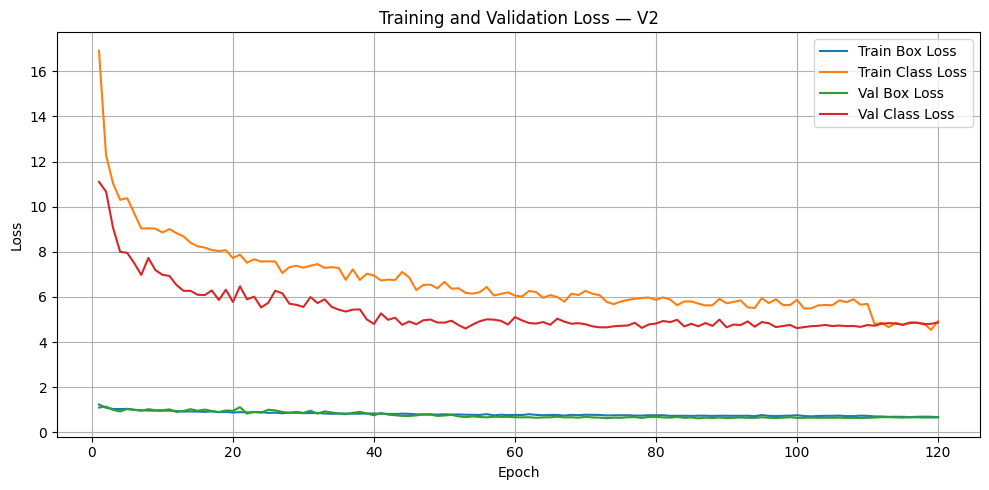

In [ ]:
# Display training and validation loss curves
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history['epoch'], history['train/box_loss'], label='Train Box Loss')
ax.plot(history['epoch'], history['train/cls_loss'], label='Train Class Loss')
ax.plot(history['epoch'], history['val/box_loss'],   label='Val Box Loss')
ax.plot(history['epoch'], history['val/cls_loss'],   label='Val Class Loss')

ax.set_title('Training and Validation Loss — V2')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

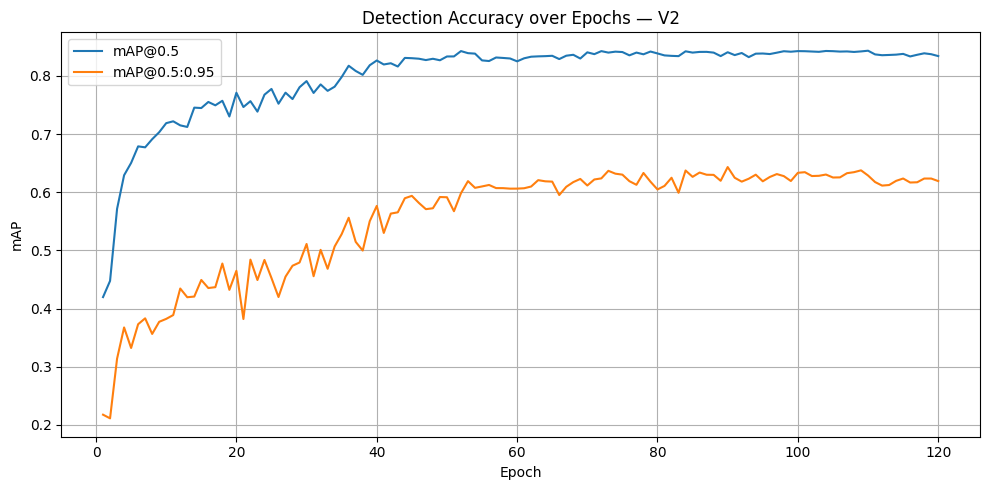

In [ ]:
# Display mAP curves over training epochs
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history['epoch'], history['metrics/mAP50(B)'],    label='mAP@0.5')
ax.plot(history['epoch'], history['metrics/mAP50-95(B)'], label='mAP@0.5:0.95')

ax.set_title('Detection Accuracy over Epochs — V2')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Load best checkpoint and run validation
gc.collect()
torch.cuda.empty_cache()

best_model = YOLO('/kaggle/working/yolo26_plasmodium_v2/weights/best.pt')

val_results = best_model.val(
    data   = f'/kaggle/working/data.yaml',
    split  = 'val',
    imgsz  = IMAGE_SIZE,
    batch  = BATCH_SIZE,
    conf   = 0.15,
    iou    = 0.5,
    device = 0,
    plots  = True
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26l summary (fused): 190 layers, 24,748,053 parameters, 0 gradients, 86.1 GFLOPs
val: Fast image access ✅ (ping: 1.0±0.1 ms, read: 776.7±577.4 MB/s, size: 1205.0 KB)
val: Scanning /kaggle/input/datasets/colabsandbox/plasmodium-merged-v2/labels/val... 237 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 237/237 236.2it/s 1.0s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/colabsandbox/plasmodium-merged-v2/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 60/60 7.8it/s 7.7s0.1s
                   all        237        744      0.752      0.797       0.83      0.648
                  Ring         99        185      0.742      0.757      0.784      0.616
              Schizont        118        237      0.774      0.886      0.902      0.738
           Trophozoite        147        322      0

In [ ]:
# Match predictions to ground truth per image
val_images_dir = f'{DATASET_DIR}/images/val'
val_labels_dir = f'{DATASET_DIR}/labels/val'

y_true, y_pred, y_scores = [], [], []

for img_file in sorted(os.listdir(val_images_dir)):
    img_path   = os.path.join(val_images_dir, img_file)
    label_path = os.path.join(val_labels_dir,
                 os.path.splitext(img_file)[0] + '.txt')

    gt_classes = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            gt_classes.append(int(parts[0]))

    preds        = best_model.predict(img_path, conf=0.15, verbose=False, device=0)
    pred_classes = []
    pred_confs   = []
    for result in preds:
        for box in result.boxes:
            pred_classes.append(int(box.cls))
            pred_confs.append(float(box.conf))

    for gt, pc, conf in zip(gt_classes, pred_classes, pred_confs):
        scores      = [0.0, 0.0, 0.0]
        scores[pc]  = conf
        y_true.append(gt)
        y_pred.append(pc)
        y_scores.append(scores)

print(f"Matched pairs: {len(y_true)}")

Matched pairs: 724


In [ ]:
# Print per class precision recall and F1
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

        Ring       0.71      0.72      0.72       175
    Schizont       0.69      0.79      0.74       232
 Trophozoite       0.80      0.70      0.74       317

    accuracy                           0.73       724
   macro avg       0.73      0.74      0.73       724
weighted avg       0.74      0.73      0.74       724



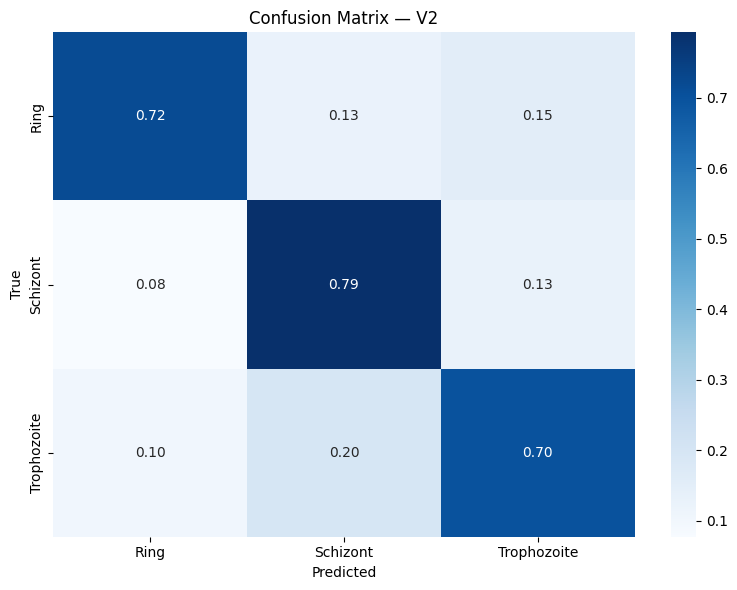

In [ ]:
# confusion matrix
cm  = confusion_matrix(y_true, y_pred, normalize='true')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=ax)

ax.set_title('Confusion Matrix — V2')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

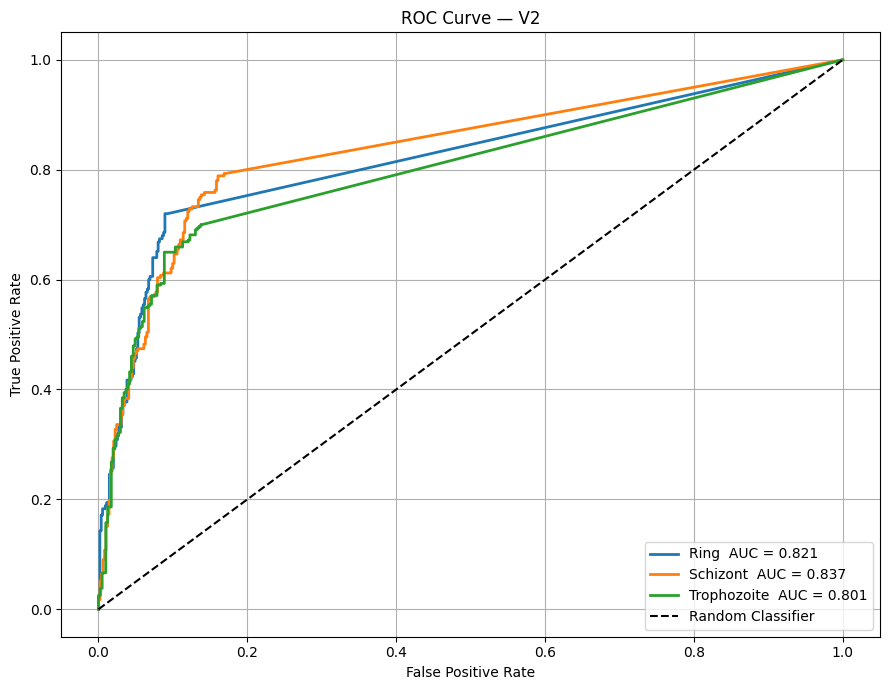

In [ ]:
#  ROC curves with AUC
y_true_bin   = label_binarize(y_true, classes=[0, 1, 2])
y_scores_arr = np.array(y_scores)

fig, ax = plt.subplots(figsize=(9, 7))
colors  = cycle(['#1f77b4', '#ff7f0e', '#2ca02c'])

for i, color in zip(range(3), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores_arr[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{CLASS_NAMES[i]}  AUC = {roc_auc:.3f}')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_title('ROC Curve — V2')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.grid(True)
plt.tight_layout()
plt.show()

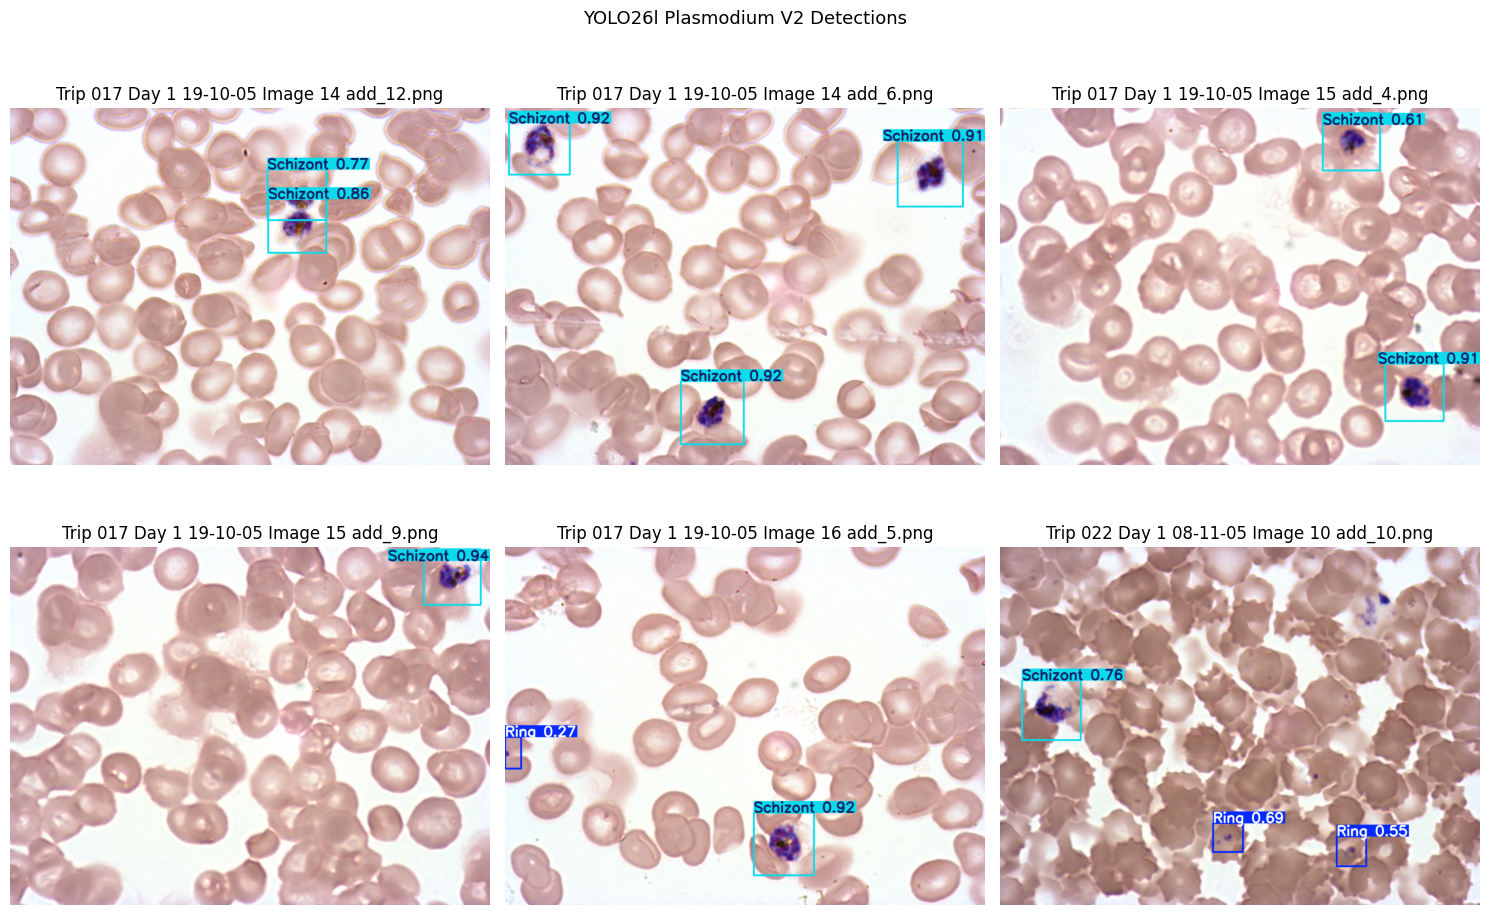

In [ ]:
# Visualize predictions
sample_files = sorted(os.listdir(val_images_dir))[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_file in enumerate(sample_files):
    img_path  = os.path.join(val_images_dir, img_file)
    result    = best_model.predict(img_path, conf=0.15,
                                   verbose=False, device=0)[0]
    annotated = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)

    axes[idx].imshow(annotated)
    axes[idx].set_title(img_file)
    axes[idx].axis('off')

plt.suptitle('YOLO26l Plasmodium V2 Detections', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Final evaluation on held out test split
test_results = best_model.val(
    data   = f'/kaggle/working/data.yaml',
    split  = 'test',
    imgsz  = IMAGE_SIZE,
    batch  = BATCH_SIZE,
    conf   = 0.15,
    iou    = 0.5,
    device = 0,
)

print(f"Test mAP@0.5:      {test_results.box.map50:.4f}")
print(f"Test mAP@0.5:0.95: {test_results.box.map:.4f}")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 20.2±5.0 MB/s, size: 153.5 KB)
val: Scanning /kaggle/input/datasets/colabsandbox/plasmodium-merged-v2/labels/test... 256 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 256/256 112.5it/s 2.3s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/colabsandbox/plasmodium-merged-v2/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 7.6it/s 8.4s0.1s
                   all        256        759      0.747      0.812       0.83      0.638
                  Ring        109        194      0.698      0.701      0.735      0.565
              Schizont        109        229      0.775       0.93      0.933       0.75
           Trophozoite        159        336       0.77      0.804      0.822      0.601
Speed: 0.8ms preprocess, 27.1ms inference, 0.0ms 

In [ ]:
# Export best model to ONNX half precision for faster inference
best_model.export(
    format = 'onnx',
    imgsz  = IMAGE_SIZE,
    half   = True,
)

print("ONNX model exported")

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/yolo26_plasmodium_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (50.5 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 321ms
Prepared 2 packages in 2.68s
Installed 2 packages in 12ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.89

requirements: AutoUpdate success ✅ 3.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 20...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.89...
ONNX: converting to FP16...
ONNX: export success ✅ 9.7s, saved as '/kaggle/working/yolo26_plasmodium_v2/weights/best.onnx' (47.5 MB)

Export complete (11.5s)
Results saved to /kaggle/working/yolo26_plasmodium_v2/weights
Predict:         yolo predict task=detect model=/kaggle/working/yolo26_plasmodium_v2/weights/best.onnx imgsz=640 half
Validate:        yolo val task=detect model=/kaggle/working/yolo26_plasmodium_v2/weights/best.onnx imgsz=640 data=/kaggle/working/data.yaml half 
Visualize:       https://netron.app
ONNX model exported


In [ ]:
# Push TensorBoard runs folder to Hugging Face
api = HfApi()

api.create_repo(
    repo_id  = HF_REPO_ID,
    token    = HF_TOKEN,
    exist_ok = True
)

api.upload_folder(
    folder_path  = RUNS_DIR,
    repo_id      = HF_REPO_ID,
    path_in_repo = 'runs/plasmodium_v2',
    token        = HF_TOKEN,
)

print(f"TensorBoard uploaded to: https://huggingface.co/{HF_REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

TensorBoard uploaded to: https://huggingface.co/codeshujaaa/kenyanmalarai-detect


In [ ]:
# Upload best model weights only
api.upload_file(
    path_or_fileobj = '/kaggle/working/yolo26_plasmodium_v2/weights/best.pt',
    path_in_repo    = 'weights/best_v2.pt',
    repo_id         = HF_REPO_ID,
    token           = HF_TOKEN,
)

print(f"V2 model uploaded to: https://huggingface.co/{HF_REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

V2 model uploaded to: https://huggingface.co/codeshujaaa/kenyanmalarai-detect


In [ ]:
# Push TensorBoard runs folder to Hugging Face
api = HfApi()

api.create_repo(
    repo_id  = HF_REPO_ID,
    token    = HF_TOKEN,
    exist_ok = True
)

api.upload_folder(
    folder_path  = RUNS_DIR,
    repo_id      = HF_REPO_ID,
    path_in_repo = 'runs/plasmodium_v2',
    token        = HF_TOKEN,
)

print(f"TensorBoard uploaded to: https://huggingface.co/{HF_REPO_ID}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


TensorBoard uploaded to: https://huggingface.co/codeshujaaa/kenyanmalarai-detect
